In [1]:
from IPython.display import display, Math

# Математика
import numpy as np
from scipy.integrate import quad
from scipy.constants import electron_mass, \
                            pi, k, \
                            elementary_charge

# Построение графиков
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Стиль графиков
import scienceplots
plt.style.use(['science', 'russian-font', 'grid'])

ValueError: All ufuncs must have type `numpy.ufunc`. Received (<ufunc 'sph_legendre_p'>, <ufunc 'sph_legendre_p'>, <ufunc 'sph_legendre_p'>)

#### Сечение возбуждения $i$-го резонансного состояния электронным ударом:
$$
    \sigma_{0i}(v) = 0.28 \times 10^{-20} \text{м}^{2} \cdot 2\pi \left( \frac{27.2\ \text{эВ}}{\Delta E_{0i}} \right) f_{0i} \frac{\ln{\left( 1 + 0.5 \sqrt{(E(v) / \Delta E_{0i}) - 1} \right)}}{(E(v) / \Delta E_{0i}) + 3},
$$
где $E(v) = \frac{1}{e} \frac{m v^2}{2}$ - кинетическая энергия электрона (в эВ).

In [ ]:
def sigma_0i(v: float, dE_0i: float, f_0i: float) -> float:
    ''' Сечение возбуждения i-го резонансного состояния атома '''
    E = (electron_mass * v**2 / 2) / elementary_charge
    return 0.28 * 1e-20 * 2 * pi * (27.2 / dE_0i) * f_0i * np.log(1 + 0.5 * np.sqrt(E / dE_0i - 1)) / (E / dE_0i + 3)

#### Функция максвелловского распределения частиц по скоростям:
$$
    f(v) = \left( \frac{m}{2\pi T_{eV}} \right)^{3/2} \exp{\left( -\frac{mv^2}{2T_{eV}} \right)}.
$$

In [ ]:
def maxwell_speed_distribution(v: float, kT: float) -> float:
    ''' Функция максвелловского распределения электронов по скоростям '''
    kT_to_J = kT * elementary_charge
    return np.sqrt((electron_mass / (2 * pi * kT_to_J))**3) * np.exp(-electron_mass * v**2 / (2 * kT_to_J))

#### Константа скорости возбуждения резонансных состояний атома:
$$
    k_{0i} = \int^{\infty}_0 v \sigma_{0i}(v) f(v) \cdot 4\pi v^2 dv = \int^{\infty}_{v_{min}} v \sigma_{0i}(v) f(v) \cdot 4\pi v^2 dv,
$$

In [ ]:
def _integrand(dE_0i: float, f_0i: float, kT: float, v: float) -> float:
    ''' Подинтегральное выражение '''
    return v * sigma_0i(v, dE_0i, f_0i) * maxwell_speed_distribution(v, kT) * (4 * pi * v**2)

def k_0i(dE_0i: float, f_0i: float, kT: float) -> np.float64:
    ''' Константа возбуждения i-го резонансного состояния атома [см^3/c] '''
    sigma = np.sqrt(kT * elementary_charge / electron_mass)
    min_velocity = np.sqrt(2 * dE_0i * elementary_charge / electron_mass)
    return quad(lambda velocity: _integrand(dE_0i, f_0i, kT, velocity), min_velocity, 1e3 * sigma)[0] * 1e6

In [ ]:
Ar_data = []
with open("ArI.txt", "r") as file:
    for line in file.readlines():
        data = line.strip(" ").replace(" ", "").split('|')
        if (len(data) > 3 and data[3] != ''): Ar_data.append(data)

He_data = []
with open("HeI.txt", "r") as file:
    for line in file.readlines():
        data = line.strip(" ").replace(" ", "").split('|')
        if (len(data) > 3 and data[3] != ''): He_data.append(data)

In [ ]:
f_0i  = []
Aki = []
dE_0i = []
low_level = []
upper_level = []

for i in range(1, len(Ar_data) - 1):
    Aki.append(Ar_data[i][1])

    f_0i.append(Ar_data[i][2])

    low_level.append(Ar_data[i][5])
    upper_level.append(Ar_data[i][7])
    
    nums = Ar_data[i][4].replace('[', '').replace(']', '').split('-')
    dE_0i.append(float(nums[1]) - float(nums[0]))

titles = Ar_data[0][:-1]
Ar_wavelengths = np.array([Ar_data[i][0] for i in range(1, len(Ar_data))], dtype = np.float64)
Ar_Aki = np.array(Aki, dtype = np.float64)
Ar_f_0i = np.array(f_0i, dtype = np.float64)
Ar_dE_0i = np.array(dE_0i, dtype = np.float64)
Ar_low_level = np.array([level.replace('<', '_{').replace('>', '}').replace('*', '^o') for level in low_level])
Ar_upper_level = np.array([level.replace('<', '_{').replace('>', '}').replace('*', '^o') for level in upper_level])

In [ ]:
f_0i  = []
Aki = []
dE_0i = []
low_level = []
upper_level = []

for i in range(1, len(He_data) - 1):
    f_0i.append(He_data[i][2]) 

    Aki.append(He_data[i][1])

    low_level.append(He_data[i][5])
    upper_level.append(He_data[i][7])
    
    nums = He_data[i][4].replace('[', '').replace(']', '').split('-')
    dE_0i.append(float(nums[1]) - float(nums[0]))

He_wavelengths = np.array([He_data[i][0] for i in range(1, len(He_data))], dtype = np.float64)
He_f_0i = np.array(f_0i, dtype = np.float64)
He_Aki = np.array(Aki, dtype = np.float64)
He_dE_0i = np.array(dE_0i, dtype = np.float64)
He_low_level = np.array([level.replace('<', '_{').replace('>', '}').replace('*', '^o') for level in low_level])
He_upper_level = np.array([level.replace('<', '_{').replace('>', '}').replace('*', '^o') for level in upper_level])

In [ ]:
# Диапазон температур
temperature = np.arange(1, 5, 0.01)

# Расчет констант скорости для каждого атома
dE_0i = He_dE_0i[np.where(He_dE_0i > 19.8)]
f_0i  = He_f_0i[np.where(He_dE_0i > 19.8)]

He_k = []
for i in range(len(f_0i)):
    He_k.append([k_0i(dE_0i[i], f_0i[i], t_i) for t_i in temperature])

He_low = He_low_level[np.where(He_dE_0i > 19.8)]
He_upper = He_upper_level[np.where(He_dE_0i > 19.8)]
He_wavelengths = He_wavelengths[np.where(He_dE_0i > 19.8)]
He_Aki = He_Aki[np.where(He_dE_0i > 19.8)]

# Расчет констант скорости для каждого атома
dE_0i = Ar_dE_0i[np.where(Ar_dE_0i > 10.8)]
f_0i  = Ar_f_0i[np.where(Ar_dE_0i > 10.8)]

Ar_k = []
for i in range(len(f_0i)):
    Ar_k.append([k_0i(dE_0i[i], f_0i[i], t_i) for t_i in temperature])

Ar_low = Ar_low_level[np.where(Ar_dE_0i > 10.8)]
Ar_upper = Ar_upper_level[np.where(Ar_dE_0i > 10.8)]
Ar_wavelengths = Ar_wavelengths[np.where(Ar_dE_0i > 10.8)]
Ar_Aki = Ar_Aki[np.where(Ar_dE_0i > 10.8)]

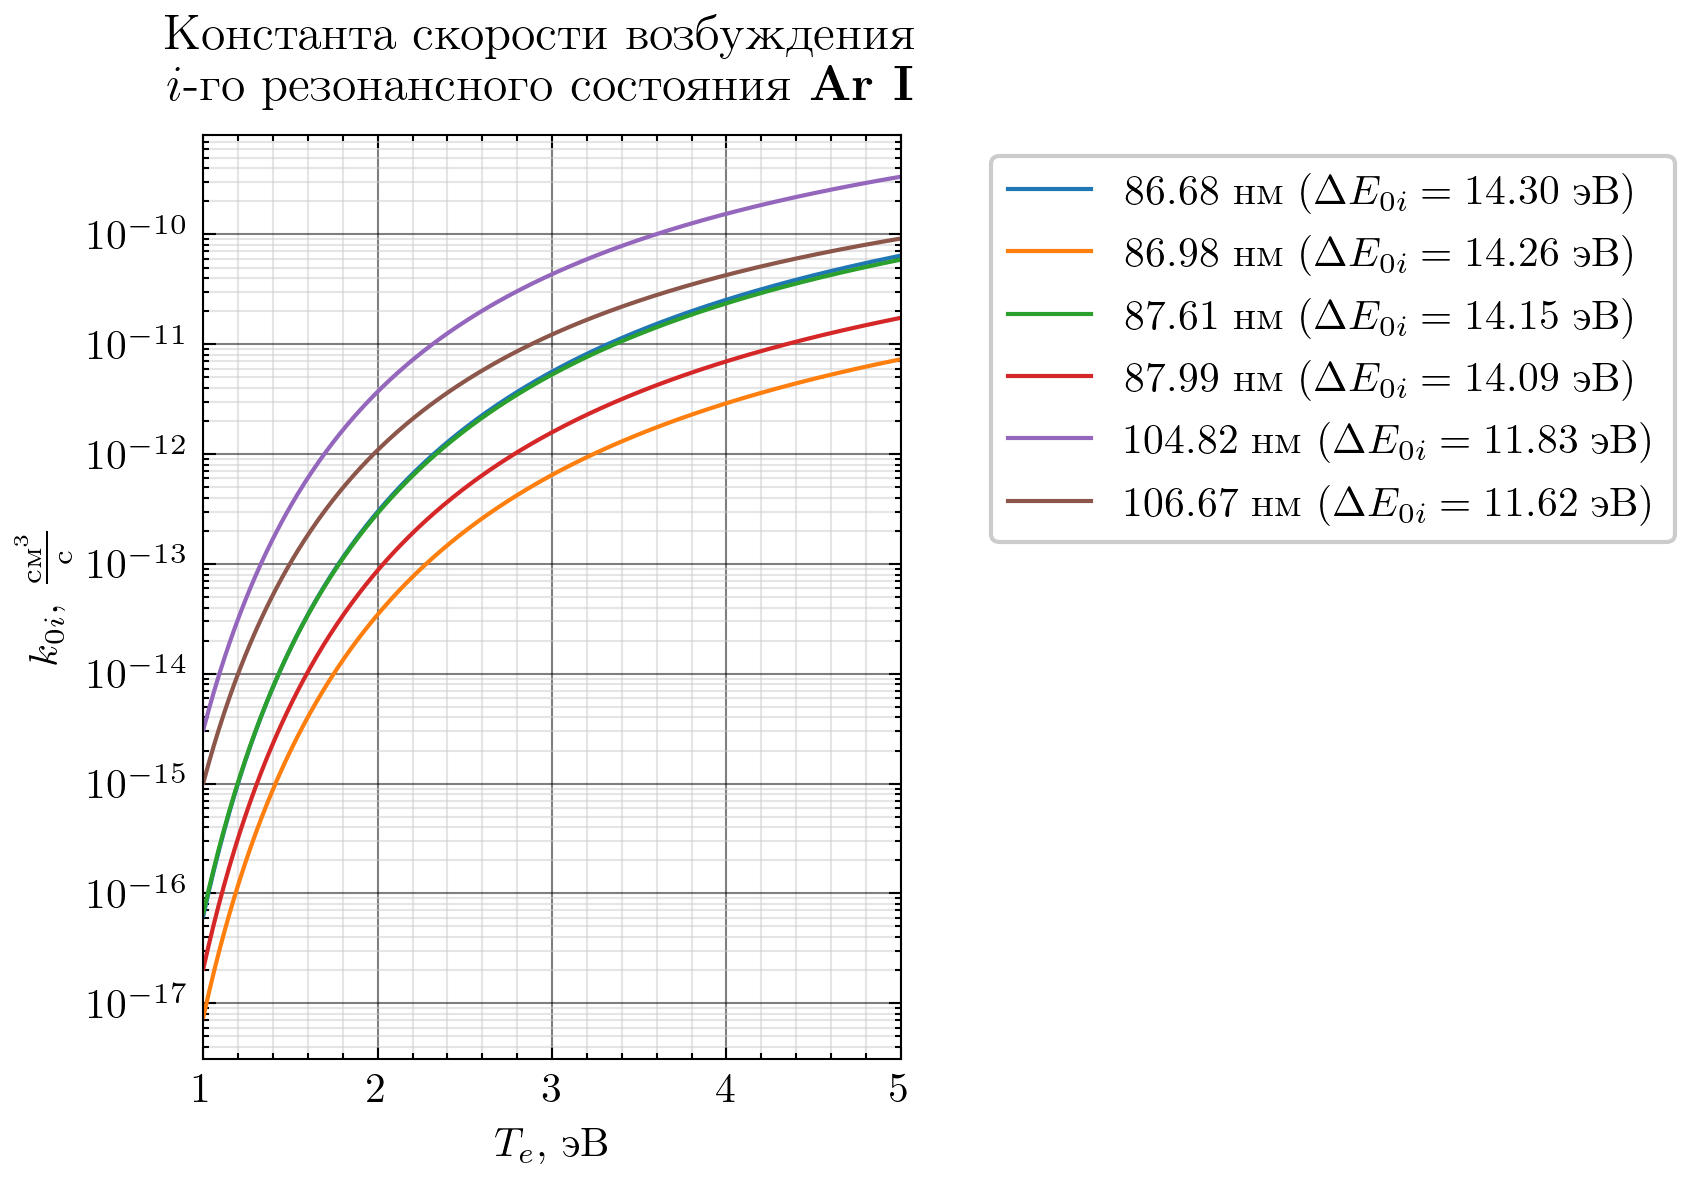

In [ ]:
fig, axisAr = plt.subplots(1, 1, dpi = 300, figsize = (3, 4))

fig.suptitle("Константа скорости возбуждения\n $i$-го резонансного состояния $\\textbf{Ar I}$")
axisAr.set_xlabel(r"$T_e$, эВ")
axisAr.set_ylabel(r"$k_{0i}$, $\frac{\text{см}^3}{\text{с}}$")
axisAr.set_xlim([1, 5])

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:cyan", "gold", "gray"]

# Построение кривых для различных переходов
for i in range(len(Ar_k)):
    # axisAr.semilogy(temperature, Ar_k[i], label = "$" + Ar_upper[i] + "\\to" + Ar_low[i] + "$ (" + f"{Ar_wavelengths[i]:.2f}" + " nm)", color = colors[i])
    axisAr.semilogy(temperature, Ar_k[i], label = f"{Ar_wavelengths[i]:.2f} нм", color = colors[i])


# Настройка логарифмического масштаба
axisAr.yaxis.set_major_locator(ticker.LogLocator(base=10,numticks=100) )
axisAr.yaxis.set_minor_locator(ticker.LogLocator(base=10,subs=np.arange(2, 10) * .1,numticks=100))
axisAr.yaxis.set_minor_formatter(ticker.NullFormatter())

# Настройка сетки
axisAr.grid(which="minor", color="0.8", linestyle='-')
axisAr.grid(linestyle='-')
axisAr.legend()

# plt.tight_layout()
plt.savefig("ArI_k0i.png", dpi = 500)
plt.show()

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Developer\AppData\Local\Temp\ipykernel_16008\58225793.py:26: SyntaxWarning: invalid escape sequence '\D'
  fig.text(.8, -.02, "Переходы из возбужденных резонансных состояний (для которых энергия возбуждения\n $\Delta E_{0i} > 19.8$ эВ энергии порогового возбуждения атома He ) в основное состояния атома $1s^2$", ha='center')


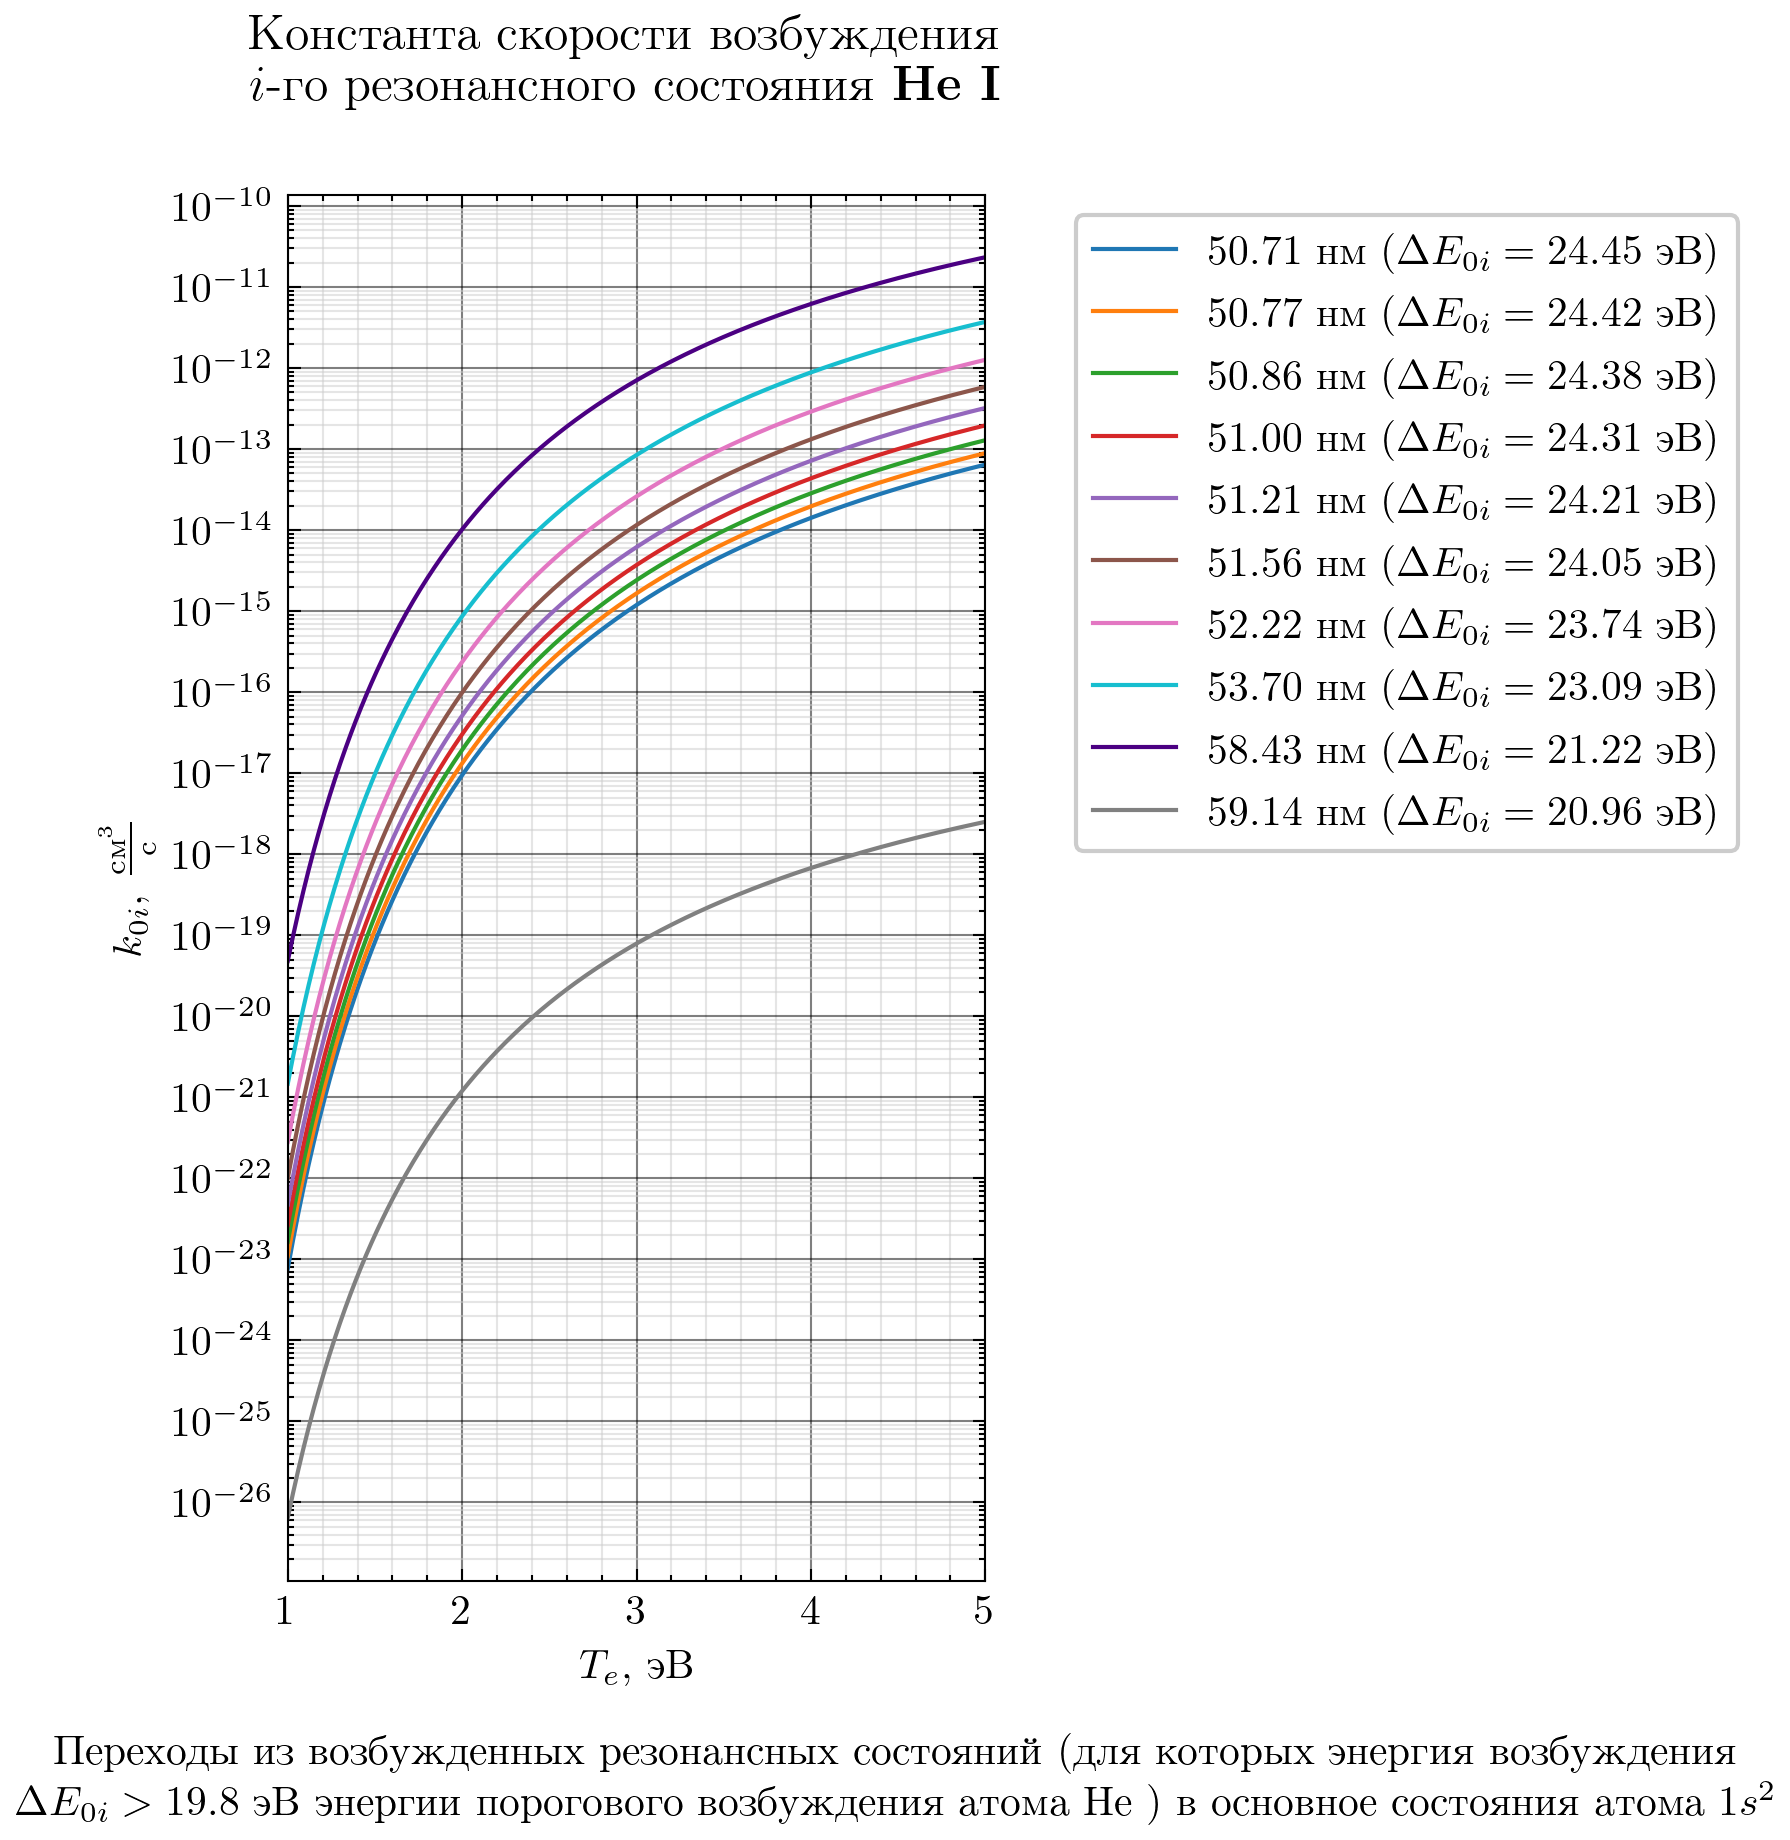

In [ ]:
fig, axisHe = plt.subplots(1, 1, dpi = 300, figsize = (3, 6))

fig.suptitle("Константа скорости возбуждения\n $i$-го резонансного состояния $\\textbf{He I}$")
axisHe.set_xlabel(r"$T_e$, эВ")
axisHe.set_ylabel(r"$k_{0i}$, $\frac{\text{см}^3}{\text{с}}$")
axisHe.set_xlim([1, 5])

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:cyan", "indigo", "gray"]

# Построение кривых для различных переходов
for i in range(len(He_k)):
    # axisHe.semilogy(temperature, He_k[i], label = "$" + He_upper[i] + "\\to" + He_low[i] + "$ (" + f"{He_wavelengths[i]:.2f}" + " nm)", color = colors[i])
    axisHe.semilogy(temperature, He_k[i], label = f"{He_wavelengths[i]:.2f} нм ($\\Delta E_{{0i}} = {He_dE_0i[np.where(He_dE_0i > 19.8)][i]:.2f}$ эВ)", color = colors[i])


# Настройка логарифмического масштаба
axisHe.yaxis.set_major_locator(ticker.LogLocator(base=10,numticks=100) )
axisHe.yaxis.set_minor_locator(ticker.LogLocator(base=10,subs=np.arange(2, 10) * .1,numticks=100))
axisHe.yaxis.set_minor_formatter(ticker.NullFormatter())

# Настройка сетки
axisHe.grid(which="minor", color="0.8", linestyle='-')
axisHe.grid(linestyle='-')
axisHe.legend(bbox_to_anchor=(1.1, 1))

fig.text(.8, -.02, "Переходы из возбужденных резонансных состояний (для которых энергия возбуждения\n $\Delta E_{0i} > 19.8$ эВ энергии порогового возбуждения атома He ) в основное состояния атома $1s^2$", ha='center')

plt.tight_layout()
plt.savefig("HeI_k0i.png", dpi = 500)
plt.show()

In [ ]:
Ar_Aki